In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

DATA_DIR = "/content/drive/MyDrive/CMPE255_Group17:MortgageLendingProject/"
RAW_PATH = os.path.join(DATA_DIR, "Raw_data", "hmda_2024_ca_snapshot.csv")

print("File exists:", os.path.exists(RAW_PATH))

File exists: True


In [ ]:
# ---- 2) Load only a sample first ----
SAMPLE_ROWS = 200000
df = pd.read_csv(RAW_PATH, nrows=SAMPLE_ROWS, low_memory=False)

print("Loaded rows:", df.shape[0], "cols:", df.shape[1])
print("\n--- Column list ---")
print(df.columns.tolist())

Loaded rows: 200000 cols: 99

--- Column list ---
['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken', 'purchaser_type', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'multifamily_affordable_units', 'income

In [ ]:
# ---- 3) Basic column summary (dtype, missing %, unique count) ----
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean() * 100,
    "n_unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

print("\n--- Summary (top 30 by missing %) ---")
display(summary.head(30))

# Save summary to Drive
os.makedirs(os.path.join(DATA_DIR, "outputs"), exist_ok=True)
summary_path = os.path.join(DATA_DIR, "outputs", "hmda_profile_column_summary.csv")
summary.to_csv(summary_path)
print("Saved:", summary_path)


--- Summary (top 30 by missing %) ---


,dtype,missing_pct,n_unique
co-applicant_ethnicity-5,float64,100.0000,0
applicant_ethnicity-5,float64,100.0000,0
applicant_ethnicity-4,float64,99.9960,4
co-applicant_ethnicity-4,float64,99.9950,3
co-applicant_race-5,float64,99.9905,9
applicant_race-5,float64,99.9785,11
co-applicant_race-4,float64,99.9520,13
co-applicant_ethnicity-3,float64,99.8990,5
applicant_race-4,float64,99.8990,13
applicant_ethnicity-3,float64,99.7555,5


Saved: /content/drive/MyDrive/CMPE255_Group17:MortgageLendingProject/outputs/hmda_profile_column_summary.csv


Column quality check:
We computed data type, % missing, and number of unique
values for each field. Columns with very high missingness (≈95–100%) are not reliable and will be dropped. We drop lei because it’s a lender ID with many unique values; models can “cheat” by learning which lenders approve more instead of learning true risk factors. Core underwriting fields (loan_amount, income, debt_to_income_ratio, loan_to_value_ratio, interest_rate, property_value) have low missingness and will be kept for modeling.

In [ ]:
# STEP 4: Applying the final filters so we work on the exact dataset cohort we want

# Home purchase only
df = df[df["loan_purpose"] == 1]

# Conventional loans only
df = df[df["loan_type"] == 1]

# Keep only clear decisions: originated (approved) and denied
df = df[df["action_taken"].isin([1, 3])]

# Create the target variable for modeling:
# approved = 1 if originated, 0 if denied
df["approved"] = (df["action_taken"] == 1).astype(int)

print("After filtering, rows and columns:", df.shape)
print(df["approved"].value_counts())
print(df["approved"].value_counts(normalize=True))

After filtering, rows and columns: (159730, 100)
approved
1    139149
0     20581
Name: count, dtype: int64
approved
1    0.871151
0    0.128849
Name: proportion, dtype: float64


After filtering to California 2024, conventional home purchase loans, and keeping only originated and denied outcomes, we obtained 159,730 applications with 87.1% approved and 12.9% denied. This class imbalance will require evaluation metrics beyond accuracy (e.g., precision/recall).

In [ ]:
# STEP 5: Check missing values in the main underwriting fields we likely want to model on
important_cols = [c for c in [
    "loan_amount", "income", "debt_to_income_ratio", "loan_to_value_ratio",
    "interest_rate", "property_value", "loan_term", "occupancy_type"
] if c in df.columns]

missing = (df[important_cols].isna().mean() * 100).sort_values(ascending=False)
missing

,0
interest_rate,12.981281
debt_to_income_ratio,7.183372
income,6.018907
loan_to_value_ratio,5.921242
property_value,1.067426
loan_term,0.269204
loan_amount,0.000000
occupancy_type,0.000000


Several underwriting fields have moderate missingness (e.g., interest_rate ~13%, DTI ~7%). To avoid losing many records, we will use a simple imputation strategy (median for numeric fields and “Unknown” for categorical buckets) before modeling.

In [ ]:
#Checking how many columns will we lose if we dropped missing values instead of imputation
cols = ["interest_rate","debt_to_income_ratio","income","loan_to_value_ratio","property_value","loan_term"]
cols = [c for c in cols if c in df.columns]

rows_before = len(df)
rows_after_drop = len(df.dropna(subset=cols))
print("Rows before:", rows_before)
print("Rows after dropping missing:", rows_after_drop)
print("Rows lost:", rows_before - rows_after_drop)

Rows before: 159730
Rows after dropping missing: 125172
Rows lost: 34558


Dropping rows with missing values would remove 34,558 records (~22% of the dataset), which is too large and may bias the sample. Therefore, we will use a simple imputation strategy (median for numeric fields and an “Unknown” category for bucketed fields) to preserve data coverage.

In [ ]:
# STEP 6: Look at the most common values in DTI and LTV fields
# This helps us understand if the column is numeric or category buckets.

if "debt_to_income_ratio" in df.columns:
    print("Top DTI values:")
    print(df["debt_to_income_ratio"].value_counts().head(15))

if "loan_to_value_ratio" in df.columns:
    print("\nTop LTV values:")
    print(df["loan_to_value_ratio"].value_counts().head(15))

Top DTI values:
debt_to_income_ratio
30%-<36%    19977
20%-<30%    15248
49          12923
48           7845
44           7609
42           7363
47           7183
43           6752
41           6535
46           6444
45           6088
>60%         6083
50%-60%      6034
40           5794
<20%         5764
Name: count, dtype: int64

Top LTV values:
loan_to_value_ratio
80           20776
80.00000      9660
95            8119
75            6977
90            4546
70            3773
95.00000      3682
75.00000      3392
90.00000      2542
97            2454
85            2352
100.00000     2350
60            1576
70.00000      1574
85.00000      1479
Name: count, dtype: int64


DTI values appear in mixed formats (both numeric values and categorical ranges like “30%–<36%”), so we will standardize DTI into consistent buckets before modeling. LTV is numeric but contains duplicate representations (e.g., 80 vs 80.00000), so we will convert it to a single numeric format.

##EDA

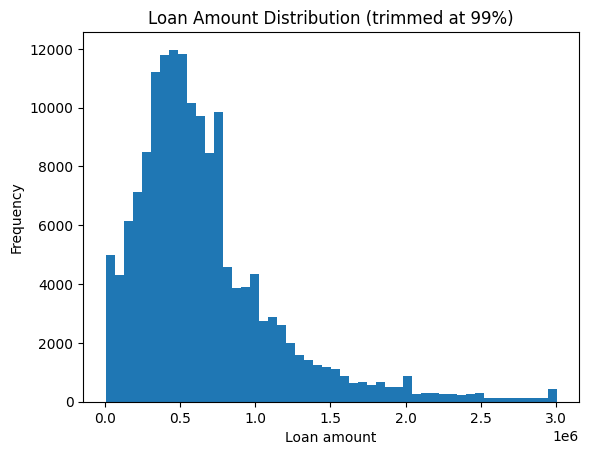

In [ ]:
import matplotlib.pyplot as plt

q99 = df["loan_amount"].quantile(0.99)
df[df["loan_amount"] <= q99]["loan_amount"].plot(kind="hist", bins=50)
plt.title("Loan Amount Distribution (trimmed at 99%)")
plt.xlabel("Loan amount")
plt.show()

The loan amount distribution is right-skewed: most conventional home-purchase loans are concentrated in the mid range, with a smaller number of very large loans forming a long tail. We trimmed the top 1% to visualize typical loan sizes clearly.

## Sanity Check

In [ ]:
# STEP A: Sanity check (helps in report)
print("Years in file:", df["activity_year"].value_counts().head())
print("States in file:", df["state_code"].value_counts().head())
print("loan_purpose values:", df["loan_purpose"].value_counts().head())
print("loan_type values:", df["loan_type"].value_counts().head())
print("action_taken values:", df["action_taken"].value_counts().head())

Years in file: activity_year
2024    159730
Name: count, dtype: int64
States in file: state_code
CA    159730
Name: count, dtype: int64
loan_purpose values: loan_purpose
1    159730
Name: count, dtype: int64
loan_type values: loan_type
1    159730
Name: count, dtype: int64
action_taken values: action_taken
1    139149
3     20581
Name: count, dtype: int64


## Fixing LTV Format

In [ ]:
#STEP 7: Converting LTV to numeric so we can analyze it cleanly
df["ltv_num"] = pd.to_numeric(df["loan_to_value_ratio"], errors="coerce")

print("LTV missing % after numeric conversion:", df["ltv_num"].isna().mean() * 100)
df["ltv_num"].describe()

LTV missing % after numeric conversion: 6.4308520628560695


,ltv_num
count,149458.000000
mean,76.014357
std,165.782303
min,0.380000
25%,67.532000
50%,80.000000
75%,89.990000
max,63668.816000


Here, max = 63668.816000, indicates the presence of outlier. As, LTV is a percentage-like number. Realistic LTV values are typically: between 0 and ~120. So, we treat LTV values outside a reasonable range as missing before analysis.


In [ ]:
import numpy as np

In [ ]:
#Step 8: Keeping only reasonable range LTV (0 < LTV ≤ 200)
df["ltv_num"] = pd.to_numeric(df["loan_to_value_ratio"], errors="coerce")
df.loc[(df["ltv_num"] <= 0) | (df["ltv_num"] > 200), "ltv_num"] = np.nan
print("LTV missing % after cleaning:", df["ltv_num"].isna().mean() * 100)
df["ltv_num"].describe()

LTV missing % after cleaning: 6.4540161522569335


,ltv_num
count,149421.000000
mean,75.492650
std,18.704286
min,0.380000
25%,67.521000
50%,80.000000
75%,89.990000
max,197.250000


Cleaning LTV was the right step because it removed unrealistic outliers without changing the typical loan patterns (median stayed 80), and it made the distribution realistic (max ~197, std dropped from 165 to 18).

## Creating LTV Buckets

In [ ]:
tmp = df[df["ltv_num"].notna()].copy()

tmp["ltv_bucket"] = pd.cut(
    tmp["ltv_num"],
    bins=[0, 60, 70, 80, 90, 95, 97, 100, 200],
    include_lowest=True
)

denial_by_ltv = 1 - tmp.groupby("ltv_bucket")["approved"].mean()
denial_by_ltv

/tmp/ipykernel_697/3719433725.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denial_by_ltv = 1 - tmp.groupby("ltv_bucket")["approved"].mean()


,approved
ltv_bucket,
"(-0.001, 60.0]",0.096507
"(60.0, 70.0]",0.094824
"(70.0, 80.0]",0.090409
"(80.0, 90.0]",0.116805
"(90.0, 95.0]",0.118147
"(95.0, 97.0]",0.132160
"(97.0, 100.0]",0.113843
"(100.0, 200.0]",0.143058


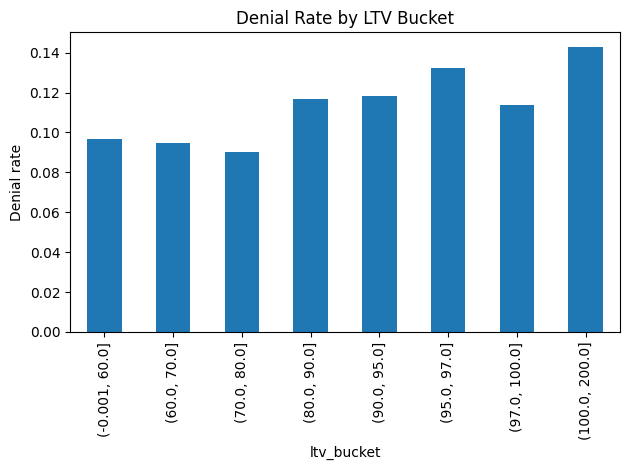

Saved to: /content/drive/MyDrive/CMPE255_Group17:MortgageLendingProject/outputs/denial_rate_by_ltv.png


In [ ]:
import matplotlib.pyplot as plt
os.makedirs(os.path.join(DATA_DIR, "outputs"), exist_ok=True)
denial_by_ltv.plot(kind="bar")
plt.title("Denial Rate by LTV Bucket")
plt.ylabel("Denial rate")
plt.tight_layout()

filepath = os.path.join(DATA_DIR, "outputs", "denial_rate_by_ltv.png")
plt.savefig(filepath, dpi=200)

plt.show()

print("Saved to:", filepath)

In [ ]:
tmp.groupby("ltv_bucket").size()

/tmp/ipykernel_697/433217958.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("ltv_bucket").size()


,0
ltv_bucket,
"(-0.001, 60.0]",28599
"(60.0, 70.0]",17696
"(70.0, 80.0]",54342
"(80.0, 90.0]",19571
"(90.0, 95.0]",15887
"(95.0, 97.0]",4487
"(97.0, 100.0]",5288
"(100.0, 200.0]",3551


We grouped loans into LTV ranges and counted how many applications fall into each range. Most loans are concentrated between 70–80% LTV and below 90% LTV, while very high LTV cases (above 95% and especially above 100%) are much less common. Because the highest-LTV buckets have fewer observations, their denial rates can show small fluctuations even though the overall trend is that higher LTV generally corresponds to higher denial risk.

## Standardize DTI into one numeric column (simple midpoint approach) + denial rate by DTI

In [ ]:
import numpy as np
import re

In [ ]:
def dti_to_number(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x.lower() == "exempt":
        return np.nan
    # numeric already
    try:
        return float(x)
    except:
        pass
    # "30%-<36%"
    m = re.match(r"(\d+)%?-<(\d+)%?", x)
    if m:
        a, b = float(m.group(1)), float(m.group(2))
        return (a + b) / 2
    # "50%-60%"
    m2 = re.match(r"(\d+)%?-(\d+)%?", x)
    if m2:
        a, b = float(m2.group(1)), float(m2.group(2))
        return (a + b) / 2
    # "<20%" or ">60%"
    m3 = re.match(r"<(\d+)%?", x)
    if m3:
        return float(m3.group(1)) - 5
    m4 = re.match(r">(\d+)%?", x)
    if m4:
        return float(m4.group(1)) + 5
    return np.nan

df["dti_num"] = df["debt_to_income_ratio"].apply(dti_to_number)
print("DTI missing %:", df["dti_num"].isna().mean() * 100)

DTI missing %: 7.692981906968009


In [ ]:
tmp = df[df["dti_num"].notna()].copy()
tmp["dti_bucket"] = pd.cut(tmp["dti_num"], bins=[0,20,30,36,40,45,50,60,200], include_lowest=True)

denial_by_dti = 1 - tmp.groupby("dti_bucket")["approved"].mean()
denial_by_dti

/tmp/ipykernel_697/458378418.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denial_by_dti = 1 - tmp.groupby("dti_bucket")["approved"].mean()


,approved
dti_bucket,
"(-0.001, 20.0]",0.164296
"(20.0, 30.0]",0.073911
"(30.0, 36.0]",0.062242
"(36.0, 40.0]",0.060093
"(40.0, 45.0]",0.066556
"(45.0, 50.0]",0.070243
"(50.0, 60.0]",0.607889
"(60.0, 200.0]",0.924379


Denial rates for (50.0, 60.0] and (60.0, 200.0] look suspiciously high and signal outliers

In [ ]:
#Validating if output is trustworthy
tmp.groupby("dti_bucket").size()

/tmp/ipykernel_697/3980021364.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dti_bucket").size()


,0
dti_bucket,
"(-0.001, 20.0]",5764
"(20.0, 30.0]",15248
"(30.0, 36.0]",24437
"(36.0, 40.0]",21134
"(40.0, 45.0]",34347
"(45.0, 50.0]",34395
"(50.0, 60.0]",6034
"(60.0, 200.0]",6083


In [ ]:
#Looking at the DTI values in 60-200
tmp[tmp["dti_bucket"] == pd.Interval(60, 200, closed='right')]["debt_to_income_ratio"].value_counts().head(20)

,count
debt_to_income_ratio,
>60%,6083


In [ ]:
# What raw values make up the (50,60] bucket?
tmp[tmp["dti_bucket"] == pd.Interval(50, 60, closed='right')]["debt_to_income_ratio"].value_counts().head(20)

# Quick sample rows from (50,60]
tmp[tmp["dti_bucket"] == pd.Interval(50, 60, closed='right')][
    ["debt_to_income_ratio", "dti_num", "approved"]
].sample(15, random_state=42)

,debt_to_income_ratio,dti_num,approved
157208,50%-60%,55.0,1
87802,50%-60%,55.0,1
152727,50%-60%,55.0,0
19711,50%-60%,55.0,1
116873,50%-60%,55.0,0
169744,50%-60%,55.0,1
153060,50%-60%,55.0,1
57225,50%-60%,55.0,1
155660,50%-60%,55.0,0
8991,50%-60%,55.0,0


In [ ]:
tmp[tmp["dti_bucket"] == pd.Interval(60, 200, closed='right')][
    ["debt_to_income_ratio", "dti_num", "approved"]
].sample(15, random_state=42)

,debt_to_income_ratio,dti_num,approved
4633,>60%,65.0,0
121488,>60%,65.0,0
140171,>60%,65.0,0
39354,>60%,65.0,0
2393,>60%,65.0,0
6961,>60%,65.0,0
143949,>60%,65.0,0
156258,>60%,65.0,0
154589,>60%,65.0,0
154632,>60%,65.0,0


After converting DTI into numeric buckets, we validated that the highest bucket (60–200) consists entirely of HMDA’s “>60%” category, not parsing errors. This group shows a very high denial rate, suggesting DTI is a strong risk signal in the conventional home-purchase cohort.

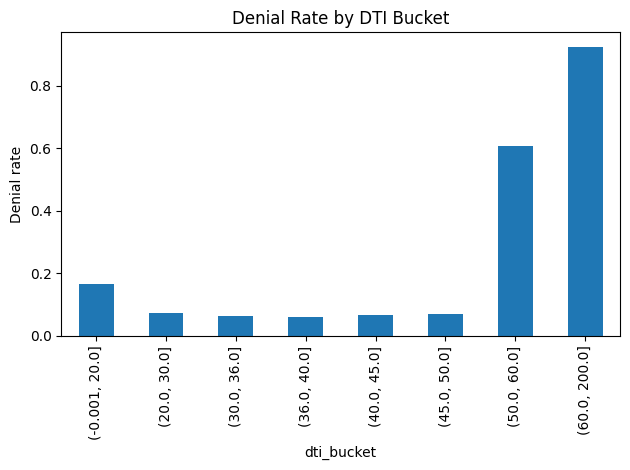

Saved to: /content/drive/MyDrive/CMPE255_Group17:MortgageLendingProject/outputs/denial_rate_by_dti.png


In [ ]:
os.makedirs(os.path.join(DATA_DIR, "outputs"), exist_ok=True)

denial_by_dti.plot(kind="bar")
plt.title("Denial Rate by DTI Bucket")
plt.ylabel("Denial rate")
plt.tight_layout()

filepath = os.path.join(DATA_DIR, "outputs", "denial_rate_by_dti.png")
plt.savefig(filepath, dpi=200)

plt.show()

print("Saved to:", filepath)
plt.close()

Denial rates are low and fairly stable for DTI between 20% and 50% (around 6–8%). However, denial rates increase sharply for high DTI: the 50–60% bucket shows much higher denial rates, and applications reported as DTI >60% show the highest denial rates. This suggests that very high DTI is a strong risk signal in our cohort.

## Saving the processed dataset

In [ ]:
import os

PROCESSED_DIR = os.path.join(DATA_DIR, "data_processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

keep_cols = [c for c in [
    "approved",
    "action_taken",
    "loan_amount",
    "income",
    "interest_rate",
    "loan_term",
    "property_value",
    "occupancy_type",
    "lien_status",
    "total_units",
    "loan_to_value_ratio",   # raw
    "ltv_num",               # cleaned numeric
    "debt_to_income_ratio",  # raw
    "dti_num",               # cleaned numeric
    "county_code",
    "census_tract",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
] if c in df.columns]

df_model = df[keep_cols].copy()

processed_path = os.path.join(PROCESSED_DIR, "hmda_2024_ca_processed_v1.csv")
df_model.to_csv(processed_path, index=False)

print("Saved:", processed_path)
print("Shape:", df_model.shape)

Saved: /content/drive/MyDrive/CMPE255_Group17:MortgageLendingProject/data_processed/hmda_2024_ca_processed_v1.csv
Shape: (159730, 20)


In [ ]:
#Checking file size of the processed data
print("File size (MB):", os.path.getsize(processed_path)/1e6)
df_model.head()

File size (MB): 16.329024


,approved,action_taken,loan_amount,income,interest_rate,loan_term,property_value,occupancy_type,lien_status,total_units,loan_to_value_ratio,ltv_num,debt_to_income_ratio,dti_num,county_code,census_tract,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage
0,1,1,375000.0,188.0,6.5,360,695000,1,1,1,54.136,54.136,30%-<36%,33.0,6071.0,6.071002e+09,11611,79.91,97500,116
1,1,1,405000.0,131.0,6.875,360,635000,1,1,1,62.59,62.590,39,39.0,6065.0,6.065048e+09,6631,52.65,97500,181
2,1,1,385000.0,100.0,6.5,360,575000,1,1,1,101.74,101.740,45,45.0,6097.0,6.097151e+09,3290,78.15,128400,63
3,1,1,955000.0,708.0,6.125,360,1185000,3,1,1,80,80.000,30%-<36%,33.0,6061.0,6.061021e+09,11223,46.00,113700,165
4,1,1,305000.0,152.0,6.99,360,415000,1,1,1,75,75.000,40,40.0,6025.0,6.025011e+09,9436,84.78,65300,175


## Algorithm

We trained baseline classification models (Logistic Regression and Random Forest) on the processed HMDA cohort to establish an initial performance benchmark. These results are preliminary; before final modeling we will (1) finalize consistent DTI handling, (2) treat interest_rate=0 as missing, (3) address extreme outliers in loan_amount/property_value (e.g., via log transform or capping), and (4) confirm no leakage features are included. The goal of this check-in is to demonstrate algorithm exploration, not final model optimization.

In [ ]:
# ------------------------------
# Algorithms (Preliminary Baselines)
#
# Note: These are baseline results; further data cleaning will be applied before final modeling.
# ------------------------------

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import os

# 1) Load processed dataset
DATA_DIR = "/content/drive/MyDrive/CMPE255_Group17:MortgageLendingProject"
PROCESSED_PATH = os.path.join(DATA_DIR, "data_processed", "hmda_2024_ca_processed_v1.csv")

dfm = pd.read_csv(PROCESSED_PATH, low_memory=False)
print("Loaded processed dataset:", dfm.shape)

# 2) Small cleanup
# interest_rate==0 is likely a placeholder; treat as missing for modeling
if "interest_rate" in dfm.columns:
    dfm.loc[dfm["interest_rate"] == 0, "interest_rate"] = np.nan

# 3) Define target + features
y = dfm["approved"].astype(int)
X = dfm.drop(columns=["approved"])

# 4) Identify numeric vs categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

# 5) Preprocessing (simple, standard):
# - numeric: median imputation
# - categorical: most-frequent imputation + one-hot
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# 6) Train/test split (stratified keeps 87/13 split in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train denial rate:", 1 - y_train.mean(), "Test denial rate:", 1 - y_test.mean())

# 7) Model A: Logistic Regression baseline (with class_weight for imbalance)
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg.fit(X_train, y_train)
log_proba = log_reg.predict_proba(X_test)[:, 1]
log_pred = (log_proba >= 0.5).astype(int)

# 8) Model B: Random Forest baseline (simple settings; can tune later)
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

# 9) Print metrics
def report_metrics(name, y_true, proba, pred):
    print("\n---", name, "---")
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    print("F1:", f1_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall:", recall_score(y_true, pred))

report_metrics("Logistic Regression (baseline)", y_test, log_proba, log_pred)
report_metrics("Random Forest (baseline)", y_test, rf_proba, rf_pred)

Loaded processed dataset: (159730, 20)
Numeric cols: ['action_taken', 'loan_amount', 'income', 'occupancy_type', 'lien_status', 'ltv_num', 'dti_num', 'county_code', 'census_tract', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage']
Categorical cols: ['interest_rate', 'loan_term', 'property_value', 'total_units', 'loan_to_value_ratio', 'debt_to_income_ratio']
Train size: (127784, 19) Test size: (31946, 19)
Train denial rate: 0.12885024729230576 Test denial rate: 0.1288424215864271

--- Logistic Regression (baseline) ---
ROC-AUC: 0.603796425402459
F1: 0.6370828873272211
Precision: 0.9039223454833597
Recall: 0.4918792669780812

--- Random Forest (baseline) ---
ROC-AUC: 0.9999999694451982
F1: 0.9999640688440947
Precision: 0.9999281402701926
Recall: 1.0


We ran two baseline models to satisfy the algorithm exploration requirement. Logistic Regression provides a reasonable baseline (ROC-AUC ≈ 0.60) with high precision but moderate recall for denials. Random Forest produced nearly perfect scores, which is unusually high for real lending data and likely indicates an issue such as feature handling or information leakage; we will validate and correct preprocessing (especially numeric fields being treated as categorical) before relying on this result.